## Regresión lineal usando scikit-learn



Cuando se hace aprendizaje automático, uno está interesado en seleccionar el modelo que minimiza el error en los datos disponibles en mayor medida. Podríamos implementar un enfoque de fuerza bruta, variando los pesos e interceptos y seleccionando el modelo con el menor error.

Afortunadamente, este problema de encontrar los mejores valores de los parámetros (es decir, aquellos que resultan en el menor error) se puede resolver sin necesidad de comprobar todas las posibles combinaciones de parámetros. De hecho, este problema tiene una solución en forma cerrada: los mejores valores de los parámetros se pueden encontrar resolviendo una ecuación. Esto evita la necesidad de una búsqueda de fuerza bruta. Esta estrategia está implementada en scikit-learn.

In [ ]:
from google.colab import drive

# Monta tu unidad de Google Drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Lee el archivo CSV desde tu Google Drive
file_path = '/content/drive/My Drive/Curso-UTEC-Estudiantes/data/penguins_regression.csv'
penguins = pd.read_csv(file_path)




In [ ]:
# Define las columnas de características y objetivo
feature_name = "Flipper Length (mm)"
target_name = "Body Mass (g)"
data, target = penguins[[feature_name]], penguins[target_name]




In [ ]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(data, target)

LinearRegression()

La instancia `linear_regression` almacena los valores de los parámetros en los atributos `coef_` e `intercept_`. Podemos verificar cuál es el modelo óptimo encontrado:

In [ ]:
weight_flipper_length = linear_regression.coef_[0]
weight_flipper_length

49.68556640610011

In [ ]:
intercept_body_mass = linear_regression.intercept_
intercept_body_mass

-5780.831358077066

Podemos utilizar el peso y el intercepto para graficar el modelo encontrado utilizando scikit-learn.

In [ ]:
import numpy as np

# Creamos un rango de valores de longitud de aleta (flipper_length) utilizando linspace
# Los valores mínimos y máximos se toman de los datos en 'data'
# Generamos 300 puntos equidistantes en este rango
flipper_length_range = np.linspace(data.min(), data.max(), num=300)

# Calculamos las predicciones de peso corporal (predicted_body_mass) utilizando
# la ecuación lineal: peso_flipper_longitud * longitud_de_aleta + intercepción_peso_corporal
predicted_body_mass = (
    weight_flipper_length * flipper_length_range + intercept_body_mass
)


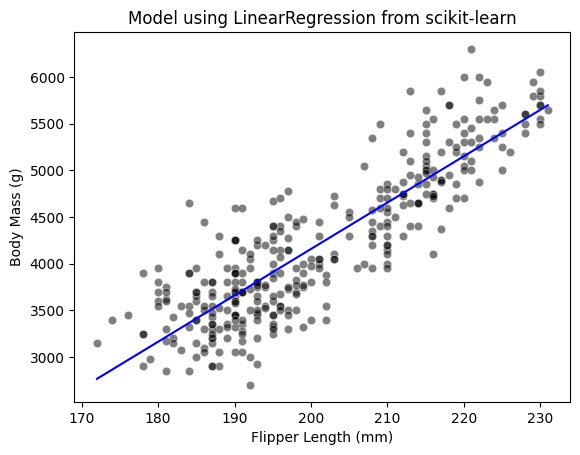

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de dispersión utilizando Seaborn
sns.scatterplot(data=data, x=feature_name, y=target, color="black", alpha=0.5)

# Gráfico de línea utilizando Seaborn para trazar la línea de predicción
# Utilizamos el método squeeze() para asegurarnos de que los arreglos sean unidimensionales
sns.lineplot(x=flipper_length_range.squeeze(), y=predicted_body_mass.squeeze(), color="blue")

# Agregamos un título al gráfico
plt.title("Model using LinearRegression from scikit-learn")

# Mostramos el gráfico
plt.show()


Vamos a medir que tan bueno es el modelo, eso es, cuanto se ajusta a los dato, usando dos métricas: (i) el [error cuadrático medio](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error) y (ii) el [error absoluto medio](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-error). Veamos cómo utilizar las implementaciones de scikit-learn a continuación.

Primero, podemos calcular el error cuadrático medio.

In [ ]:
from sklearn.metrics import mean_squared_error

inferred_body_mass = linear_regression.predict(data)
model_error = mean_squared_error(target, inferred_body_mass)
print(f"The mean squared error of the optimal model is {model_error:.2f}")

The mean squared error of the optimal model is 154546.19


Un modelo de regresión lineal minimiza el error cuadrático medio en el conjunto de entrenamiento. Esto significa que los parámetros obtenidos después del ajuste (es decir, `coef_` e `intercept_`) son los parámetros óptimos que minimizan el error cuadrático medio. En otras palabras, cualquier otra elección de parámetros produciría un modelo con un error cuadrático medio más alto en el conjunto de entrenamiento.

Sin embargo, el error cuadrático medio es difícil de interpretar. El error absoluto medio es más intuitivo, ya que proporciona un error en la misma unidad que el objetivo.

In [ ]:
from sklearn.metrics import mean_absolute_error

model_error = mean_absolute_error(target, inferred_body_mass)
print(f"The mean absolute error of the optimal model is {model_error:.2f} g")

The mean absolute error of the optimal model is 313.00 g


Un error absoluto medio de 313 significa que, en promedio, nuestro modelo comete un error de ± 313 gramos al predecir el peso corporal de un pingüino dado su longitud de aleta.